In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("train.csv")

print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

Dataset shape: (9800, 18)
Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


In [3]:
print("Missing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Missing values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Data types:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
dtype: object


In [4]:
print("Sales statistics:")
print(df["Sales"].describe())

Sales statistics:
count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64


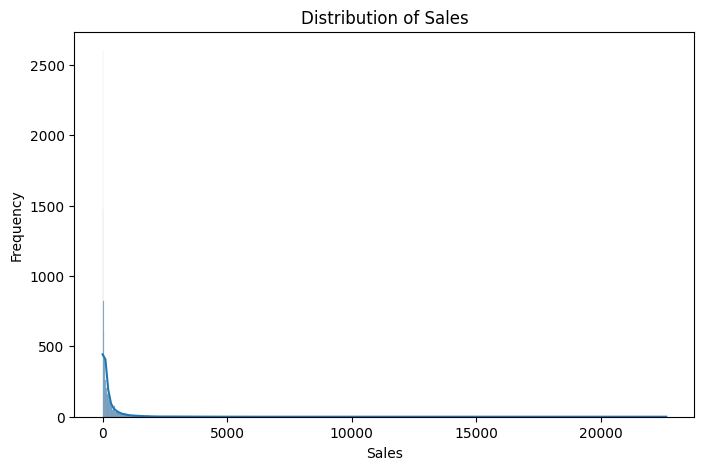

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df["Sales"], kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

In [6]:
# Remove rows with missing values
df = df.dropna()

# Convert categorical columns into numerical columns
X = df.drop("Sales", axis=1)
y = df["Sales"]

X = pd.get_dummies(X, drop_first=True)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (9789, 13361)
Target shape: (9789,)


In [9]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.2 MB 8.5 MB/s eta 0:00:01
   -------- ------------------------------- 1.8/8.2 MB 6.3 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.2 MB 6.2 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.2 MB 6.5 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.2 MB 6.8 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 7.0 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
from sklearn.ensemble import RandomForestRegressor

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (7831, 13361)
Testing data: (1958, 13361)


In [12]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [13]:
y_pred = model.predict(X_test)

print("Predictions completed!")
print(y_pred[:10])

Predictions completed!
[ 561.666      77.41476   113.23432    50.0406   1321.87294   166.67943
  356.682612   78.70466    20.49363    20.27502 ]


In [14]:
y_pred = model.predict(X_test)

print("Predictions completed!")
print(y_pred[:10])

Predictions completed!
[ 561.666      77.41476   113.23432    50.0406   1321.87294   166.67943
  356.682612   78.70466    20.49363    20.27502 ]


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-------------------------")
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Model Evaluation
-------------------------
Mean Absolute Error: 154.0446300199183
Root Mean Squared Error: 459.38622196464945
R² Score: 0.5685521410589984


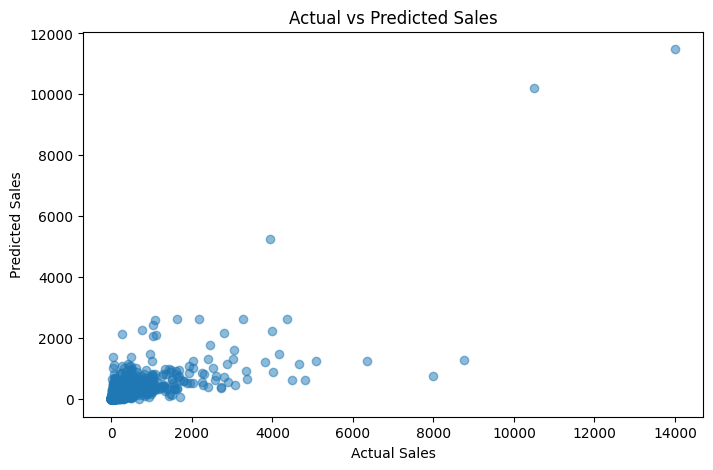

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

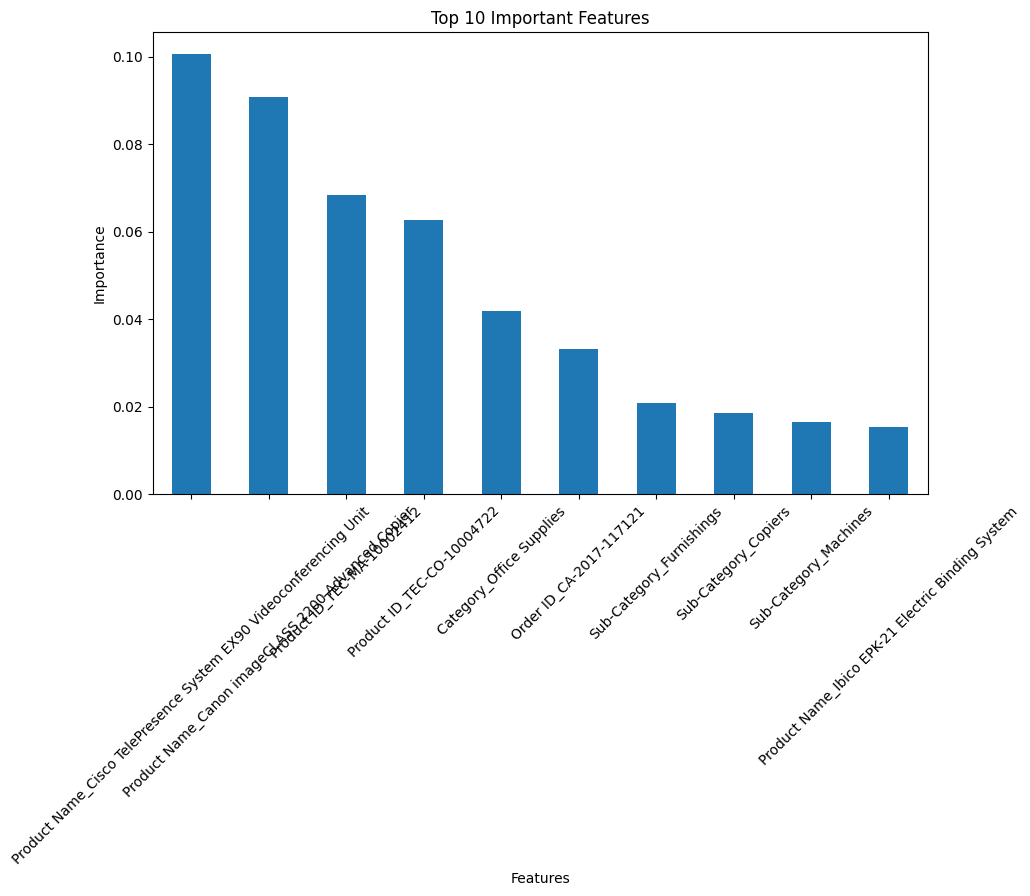

In [17]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

importance.head(10).plot(kind="bar")

plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)
plt.show()

In [18]:
results = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

display(results.head(20))

,Actual Sales,Predicted Sales
0,273.960,561.666000
1,62.880,77.414760
2,11.680,113.234320
3,7.712,50.040600
4,2399.960,1321.872940
5,8.640,166.679430
6,212.058,356.682612
7,122.328,78.704660
8,49.568,20.493630
9,8.712,20.275020


In [19]:
results.to_csv("sales_predictions.csv", index=False)

print("Prediction results saved successfully!")

Prediction results saved successfully!


# Conclusion

The objective of this project was to build a machine learning model for predicting sales outcomes.

The dataset was cleaned and preprocessed before training the model. A Random Forest Regression model was trained using the available features and evaluated on unseen test data.

The model performance was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score. Actual versus predicted sales and feature importance were also visualized.

The results demonstrate how supervised machine learning can be used to predict sales and identify the features that contribute to the prediction.